In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from diffusers import UNet2DModel
from diffusers import DDPMScheduler
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm.auto import tqdm
from torchvision.transforms import ToPILImage
from IPython.display import display

torch.set_float32_matmul_precision('high')
torch.backends.cudnn.enabled = False



In [19]:

class ConditionalDDPM(nn.Module):
    def __init__(self, num_classes=10, model_id="google/ddpm-cifar10-32"):
        super().__init__()
        
        #Load pre-trained model
        self.unet = UNet2DModel.from_pretrained(model_id)
        
        # Extract the exact time embedding dimension (same as class embedding)
     
        time_embed_dim = self.unet.time_embedding.linear_2.out_features
        # add the class embedding layer
        self.unet.class_embedding = nn.Embedding(num_classes, time_embed_dim)
        
        nn.init.normal_(self.unet.class_embedding.weight, std=0.02)

    def forward(self, sample, timestep, class_labels):
        return self.unet(sample, timestep, class_labels=class_labels).sample


#Create and compile model
model = ConditionalDDPM(num_classes=11)
model = torch.compile(model)


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
/home/aneesh_shastri/miniforge3/envs/ml_env/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [20]:

def get_cifar10_splits(batch_size=64, val_split=0.1, seed=42):
    """
    Splits CIFAR-10 into Train, Validation, and Test sets, 
    applying proper diffusion normalization [-1, 1].
    """
    # 1. Standard Diffusion Preprocessing (Maps [0, 1] to [-1, 1])
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    # Download Train and  Test dataset
    full_train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
    

    val_size = int(len(full_train_dataset) * val_split)
    train_size = len(full_train_dataset) - val_size   
    
    #Set seed
    generator = torch.Generator().manual_seed(seed)
    
    # train-val split
    train_dataset, val_dataset = random_split(
        full_train_dataset, 
        [train_size, val_size], 
        generator=generator
    )
    
    # 4. Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, drop_last=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, drop_last=False)
    
    return train_loader, val_loader, test_loader

# create dataloaders
train_loader, val_loader, test_loader = get_cifar10_splits(batch_size=128)

print(f"Train batches: {len(train_loader)} (~{len(train_loader)*128} images)")
print(f"Validation batches: {len(val_loader)} (~{len(val_loader)*128} images)")
print(f"Test batches: {len(test_loader)} (~{len(test_loader)*128} images)")

Train batches: 351 (~44928 images)
Validation batches: 40 (~5120 images)
Test batches: 79 (~10112 images)


In [ ]:


def train_cond_ddpm(model, train_loader, val_loader, epochs=5, lr=2e-5, device="cuda"):
    """
    Fine-tunes the ConditionalDDPM with per-epoch validation.
    Returns a dict of training history for plotting.
    """
    model = model.to(device)
    
    # Differential learning rates
    optimizer = optim.AdamW([
        {"params": model.unet.class_embedding.parameters(), "lr": lr*100},
        {"params": model.unet.time_embedding.parameters(), "lr": lr*10},
        {"params": [p for n, p in model.unet.named_parameters()
                    if "class_embedding" not in n and "time_embedding" not in n], "lr": lr}
    ])
    
    noise_scheduler = DDPMScheduler.from_pretrained("google/ddpm-cifar10-32")
    num_train_timesteps = noise_scheduler.config.num_train_timesteps

    history = {"train_loss": [], "val_loss": []}
    print(f"Starting fine-tuning on device: {device}...")
    
    for epoch in range(epochs):
        # ── Training ──────────────────────────────────────────────────────
        model.train()
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [train]")
        epoch_loss = 0.0
        
        for step, (clean_images, class_labels) in enumerate(progress_bar):
            clean_images = clean_images.to(device)
            class_labels = class_labels.clone().to(device)   # clone to avoid in-place DataLoader mutation
            batch_size = clean_images.shape[0]

            # CFG dropout: 10% of the time, replace class with NULL token
            dropout_mask = torch.rand(batch_size, device=device) < 0.1
            class_labels[dropout_mask] = 10

            timesteps = torch.randint(0, num_train_timesteps, (batch_size,), device=device).long()
            noise = torch.randn_like(clean_images)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)
            
            noise_pred = model(noisy_images, timesteps, class_labels=class_labels)
            loss = F.mse_loss(noise_pred, noise)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            progress_bar.set_postfix({"batch_loss": f"{loss.item():.4f}"})
        
        avg_train = epoch_loss / len(train_loader)
        history["train_loss"].append(avg_train)

        # ── Validation ────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for clean_images, class_labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [val]", leave=False):
                clean_images = clean_images.to(device)
                class_labels = class_labels.to(device)
                batch_size = clean_images.shape[0]

                timesteps = torch.randint(0, num_train_timesteps, (batch_size,), device=device).long()
                noise = torch.randn_like(clean_images)
                noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

                noise_pred = model(noisy_images, timesteps, class_labels=class_labels)
                val_loss += F.mse_loss(noise_pred, noise).item()

        avg_val = val_loss / len(val_loader)
        history["val_loss"].append(avg_val)

        print(f"Epoch {epoch+1} Complete — Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")
    
    return history


history = train_cond_ddpm(model, train_loader, val_loader, epochs=10, lr=1e-5)


Starting fine-tuning on device: cuda...


Epoch 1/10 [train]:   0%|          | 0/351 [00:00<?, ?it/s]

Epoch 1/10 [val]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1 Complete — Train Loss: 0.0277 | Val Loss: 0.0259


Epoch 2/10 [train]:   0%|          | 0/351 [00:00<?, ?it/s]

In [ ]:

def evaluate_on_test(model, test_loader, device="cuda"):
    """
    Computes the average noise-prediction MSE loss on the test set.
    """
    model.eval()
    noise_scheduler = DDPMScheduler.from_pretrained("google/ddpm-cifar10-32")
    num_train_timesteps = noise_scheduler.config.num_train_timesteps

    test_loss = 0.0
    num_batches = 0

    with torch.no_grad():
        for clean_images, class_labels in tqdm(test_loader, desc="Evaluating on test set"):
            clean_images = clean_images.to(device)
            class_labels = class_labels.to(device)
            batch_size = clean_images.shape[0]

            timesteps = torch.randint(0, num_train_timesteps, (batch_size,), device=device).long()
            noise = torch.randn_like(clean_images)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            noise_pred = model(noisy_images, timesteps, class_labels=class_labels)
            test_loss += F.mse_loss(noise_pred, noise).item()
            num_batches += 1

    avg_test_loss = test_loss / num_batches
    print(f"\nTest Set — Average Noise Prediction MSE: {avg_test_loss:.6f}")
    return avg_test_loss


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_mse = evaluate_on_test(model, test_loader, device=device)


In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
torch.save(model.state_dict(), 'model_weights.pth')
scheduler = DDPMScheduler.from_pretrained("google/ddpm-cifar10-32")

# using 4 sample batches
batch_size = 4
desired_class = 0  # Plane 

# create a tensor of planes
class_labels = torch.full((batch_size,), desired_class, dtype=torch.long, device=device)

#pure noise
sample_size = model.unet.config.sample_size
noisy_sample = torch.randn(batch_size, 3, sample_size, sample_size).to(device)


guidance_scale = 3.0  # Try 3.0 to 5.0 for strong class adherence

for t in tqdm(scheduler.timesteps, desc="Generating images"):
    # Setup dual labels for CFG
    cond_labels = torch.full((batch_size,), desired_class, dtype=torch.long, device=device)
    uncond_labels = torch.full((batch_size,), 10, dtype=torch.long, device=device) 
    
    # Concatenate inputs to run through U-Net simultaneously
    double_sample = torch.cat([noisy_sample, noisy_sample])
    double_labels = torch.cat([cond_labels, uncond_labels])
    
    with torch.no_grad():
        # Predict noise for both conditional and unconditional paths
        noise_pred_all = model(double_sample, t, class_labels=double_labels)
        noise_pred_cond, noise_pred_uncond = noise_pred_all.chunk(2)
        
    #  CFG Extrapolation Step
    noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)
        
    #  Step backwards
    noisy_sample = scheduler.step(noise_pred, t, noisy_sample).prev_sample


image_tensor = (noisy_sample / 2 + 0.5).clamp(0, 1)


/home/aneesh_shastri/miniforge3/envs/ml_env/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Generating images:   0%|          | 0/1000 [00:00<?, ?it/s]

Displaying generated images for class code 0:


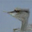

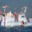

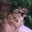

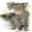

In [ ]:

to_pil = ToPILImage()

print(f"Displaying generated images for class code {desired_class}:")
for i in range(batch_size):
    img = to_pil(image_tensor[i].cpu())
    display(img)  
    img.save(f"output_{i}.png")#save images
